## bank-marketing
The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be (or not) subscribed.

The classification goal is to predict if the client will subscribe a term deposit (variable y).

In [5]:

pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install imblearn

  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0
Note: you may need to restart the kernel to use updated packages.


In [1]:
from sklearn import preprocessing
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

In [2]:
from scipy.io.arff import loadarff
raw_data = loadarff("phpkIxskf.arff")
print(raw_data[1])
df = pd.DataFrame(raw_data[0])
df.head()

Dataset: bank-marketing-full
	V1's type is numeric
	V2's type is nominal, range is ('admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
	V3's type is nominal, range is ('divorced', 'married', 'single')
	V4's type is nominal, range is ('primary', 'secondary', 'tertiary', 'unknown')
	V5's type is nominal, range is ('no', 'yes')
	V6's type is numeric
	V7's type is nominal, range is ('no', 'yes')
	V8's type is nominal, range is ('no', 'yes')
	V9's type is nominal, range is ('cellular', 'telephone', 'unknown')
	V10's type is numeric
	V11's type is nominal, range is ('apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep')
	V12's type is numeric
	V13's type is numeric
	V14's type is numeric
	V15's type is numeric
	V16's type is nominal, range is ('failure', 'other', 'success', 'unknown')
	Class's type is nominal, range is ('1', '2')



,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58.0,b'management',b'married',b'tertiary',b'no',2143.0,b'yes',b'no',b'unknown',5.0,b'may',261.0,1.0,-1.0,0.0,b'unknown',b'1'
1,44.0,b'technician',b'single',b'secondary',b'no',29.0,b'yes',b'no',b'unknown',5.0,b'may',151.0,1.0,-1.0,0.0,b'unknown',b'1'
2,33.0,b'entrepreneur',b'married',b'secondary',b'no',2.0,b'yes',b'yes',b'unknown',5.0,b'may',76.0,1.0,-1.0,0.0,b'unknown',b'1'
3,47.0,b'blue-collar',b'married',b'unknown',b'no',1506.0,b'yes',b'no',b'unknown',5.0,b'may',92.0,1.0,-1.0,0.0,b'unknown',b'1'
4,33.0,b'unknown',b'single',b'unknown',b'no',1.0,b'no',b'no',b'unknown',5.0,b'may',198.0,1.0,-1.0,0.0,b'unknown',b'1'


In [3]:
df.rename(columns = {'V1':'age','V2':'job','V3':'material','V4':'education','V5':'default','V6':'balance','V7':'housing',
                                        'V8':'loan','V9':'contact','V10':'day','V11':'month','V12':'duration','V13':'campaign','V14':'pdays',
                                        'V15':'previous','V16':'poutcome','Class':'y'},inplace = True)

In [4]:
df.head()

,age,job,material,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,b'management',b'married',b'tertiary',b'no',2143.0,b'yes',b'no',b'unknown',5.0,b'may',261.0,1.0,-1.0,0.0,b'unknown',b'1'
1,44.0,b'technician',b'single',b'secondary',b'no',29.0,b'yes',b'no',b'unknown',5.0,b'may',151.0,1.0,-1.0,0.0,b'unknown',b'1'
2,33.0,b'entrepreneur',b'married',b'secondary',b'no',2.0,b'yes',b'yes',b'unknown',5.0,b'may',76.0,1.0,-1.0,0.0,b'unknown',b'1'
3,47.0,b'blue-collar',b'married',b'unknown',b'no',1506.0,b'yes',b'no',b'unknown',5.0,b'may',92.0,1.0,-1.0,0.0,b'unknown',b'1'
4,33.0,b'unknown',b'single',b'unknown',b'no',1.0,b'no',b'no',b'unknown',5.0,b'may',198.0,1.0,-1.0,0.0,b'unknown',b'1'


In [5]:
df.dtypes

age          float64
job           object
material      object
education     object
default       object
balance      float64
housing       object
loan          object
contact       object
day          float64
month         object
duration     float64
campaign     float64
pdays        float64
previous     float64
poutcome      object
y             object
dtype: object

In [6]:
df.isna().sum()

age          0
job          0
material     0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
df['default'] = df['default'].replace({b'yes' : 0 , b'no' :1})
df['housing'] = df['housing'].replace({b'yes' : 0 , b'no' :1})
df['loan'] = df['loan'].replace({b'yes' : 0 , b'no' :1})
df.head()

,age,job,material,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,b'management',b'married',b'tertiary',1,2143.0,0,1,b'unknown',5.0,b'may',261.0,1.0,-1.0,0.0,b'unknown',b'1'
1,44.0,b'technician',b'single',b'secondary',1,29.0,0,1,b'unknown',5.0,b'may',151.0,1.0,-1.0,0.0,b'unknown',b'1'
2,33.0,b'entrepreneur',b'married',b'secondary',1,2.0,0,0,b'unknown',5.0,b'may',76.0,1.0,-1.0,0.0,b'unknown',b'1'
3,47.0,b'blue-collar',b'married',b'unknown',1,1506.0,0,1,b'unknown',5.0,b'may',92.0,1.0,-1.0,0.0,b'unknown',b'1'
4,33.0,b'unknown',b'single',b'unknown',1,1.0,1,1,b'unknown',5.0,b'may',198.0,1.0,-1.0,0.0,b'unknown',b'1'


In [8]:
df["y"].value_counts()

b'1'    39922
b'2'     5289
Name: y, dtype: int64

In [9]:
df['y'] = df['y'].replace({b'2' : 1 , b'1' :0})

In [10]:
df.dtypes

age          float64
job           object
material      object
education     object
default        int64
balance      float64
housing        int64
loan           int64
contact       object
day          float64
month         object
duration     float64
campaign     float64
pdays        float64
previous     float64
poutcome      object
y              int64
dtype: object

In [11]:
df.describe()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,0.981973,1362.272058,0.444162,0.839774,15.806419,258.163080,2.763841,40.197828,0.580323,0.116985
std,10.618762,0.133049,3044.765829,0.496878,0.366820,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,0.000000,-8019.000000,0.000000,0.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,1.000000,72.000000,0.000000,1.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,1.000000,448.000000,0.000000,1.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1.000000,1428.000000,1.000000,1.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,1.000000,102127.000000,1.000000,1.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


In [12]:
df.duplicated().sum()

0

In [13]:
updated_df = df.drop(["job","material","education","contact","month","poutcome"], axis=1)

#### Clustering Algorithm -> K-Means

Text(0, 0.5, 'WCSS')

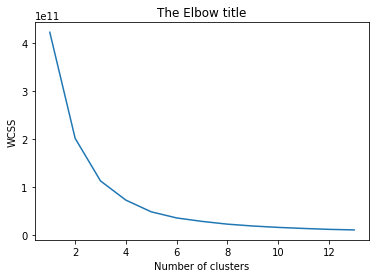

In [14]:
wcss=[]
for i in range(1,14):
    kmeans = KMeans(i)
    kmeans.fit(updated_df)
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)

number_clusters = range(1,14)
plt.plot(number_clusters,wcss)
plt.title('The Elbow title')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [15]:
kmeans = KMeans(3)
kmeans.fit(updated_df)

KMeans(n_clusters=3)

In [16]:
identified_clusters = kmeans.fit_predict(updated_df)
identified_clusters

array([0, 0, 0, ..., 2, 0, 0])

(0.0, 107634.3)

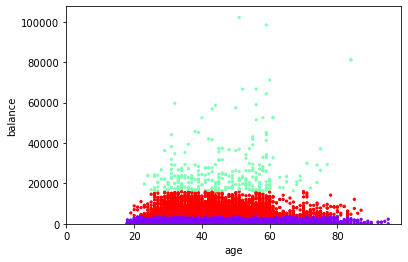

In [17]:
data_with_clusters = df.copy()
data_with_clusters['Clusters'] = identified_clusters 
plt.scatter(data_with_clusters ['age'],data_with_clusters ['balance'],c=data_with_clusters['Clusters'],cmap='rainbow', s=5)
plt.xlabel('age')
plt.ylabel('balance')
plt.xlim(0,None)
plt.ylim(0,None)

In [18]:
x = updated_df.drop(["y"], axis=1)

In [19]:
x

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous
0,58.0,1,2143.0,0,1,5.0,261.0,1.0,-1.0,0.0
1,44.0,1,29.0,0,1,5.0,151.0,1.0,-1.0,0.0
2,33.0,1,2.0,0,0,5.0,76.0,1.0,-1.0,0.0
3,47.0,1,1506.0,0,1,5.0,92.0,1.0,-1.0,0.0
4,33.0,1,1.0,1,1,5.0,198.0,1.0,-1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
45206,51.0,1,825.0,1,1,17.0,977.0,3.0,-1.0,0.0
45207,71.0,1,1729.0,1,1,17.0,456.0,2.0,-1.0,0.0
45208,72.0,1,5715.0,1,1,17.0,1127.0,5.0,184.0,3.0
45209,57.0,1,668.0,1,1,17.0,508.0,4.0,-1.0,0.0


In [20]:
y = data_with_clusters["y"]

In [21]:
y

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, Length: 45211, dtype: int64

In [22]:
y.value_counts()

0    39922
1     5289
Name: y, dtype: int64

## Imbalanced-Dataset

#### SMOTE

In [23]:
#Smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=3)

x_smote, y_smote = smote.fit_resample(x, y)

print('Original dataset shape', y.value_counts())
print('Resample dataset shape', y_smote.value_counts())

Original dataset shape 0    39922
1     5289
Name: y, dtype: int64
Resample dataset shape 0    39922
1    39922
Name: y, dtype: int64


In [24]:
x_smote

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous
0,58.000000,1,2143.000000,0,1,5.000000,261.000000,1.000000,-1.000000,0.000000
1,44.000000,1,29.000000,0,1,5.000000,151.000000,1.000000,-1.000000,0.000000
2,33.000000,1,2.000000,0,0,5.000000,76.000000,1.000000,-1.000000,0.000000
3,47.000000,1,1506.000000,0,1,5.000000,92.000000,1.000000,-1.000000,0.000000
4,33.000000,1,1.000000,1,1,5.000000,198.000000,1.000000,-1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
79839,26.599665,1,1899.793978,1,1,17.064771,255.734225,1.000000,91.734225,2.599665
79840,27.540462,1,-256.734678,0,0,12.410984,604.572831,2.475723,334.540462,2.475723
79841,25.366853,1,469.953817,1,1,21.330167,272.743203,1.000000,86.036685,1.000000
79842,40.089199,1,777.821602,0,0,24.369478,1000.248362,1.000000,-1.000000,0.000000


#### TomeLinks

In [25]:
#TomeLinks not worked
from imblearn.under_sampling import TomekLinks

tl = TomekLinks(sampling_strategy='majority')

# fit predictor and target variable
x_tl, y_tl = tl.fit_resample(x, y)

print('Original dataset shape', y.value_counts())
print('Resample dataset shape', y_tl.value_counts())

Original dataset shape 0    39922
1     5289
Name: y, dtype: int64
Resample dataset shape 0    38084
1     5289
Name: y, dtype: int64


In [26]:
#again doing TO TomekLinks
from imblearn.under_sampling import TomekLinks

tl = TomekLinks(sampling_strategy='majority')

# fit predictor and target variable
x_tl, y_tl = tl.fit_resample(x_tl, y_tl)

print('Original dataset shape', y.value_counts())
print('Resample dataset shape', y_tl.value_counts())

Original dataset shape 0    39922
1     5289
Name: y, dtype: int64
Resample dataset shape 0    37518
1     5289
Name: y, dtype: int64


#### NearMiss

In [27]:
#NearMiss
from imblearn.under_sampling import NearMiss

nm = NearMiss()

x_nm, y_nm = nm.fit_resample(x, y)

print('Original dataset shape:', y.value_counts())
print('Resample dataset shape:', y_nm.value_counts())

Original dataset shape: 0    39922
1     5289
Name: y, dtype: int64
Resample dataset shape: 0    5289
1    5289
Name: y, dtype: int64


#### RandomOverSampling

In [28]:

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

x_ros, y_ros = ros.fit_resample(x, y)

print('Original dataset shape',y.value_counts())
print('Resample dataset shape',y_ros.value_counts())

Original dataset shape 0    39922
1     5289
Name: y, dtype: int64
Resample dataset shape 0    39922
1    39922
Name: y, dtype: int64


### Outliers detection

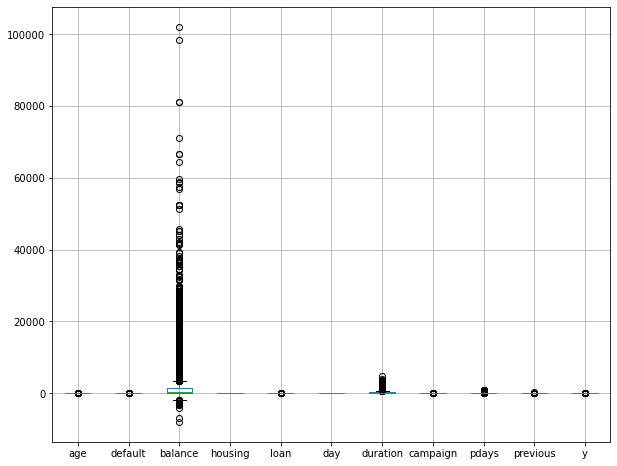

In [29]:
boxplot =updated_df.boxplot( figsize=(10,8))

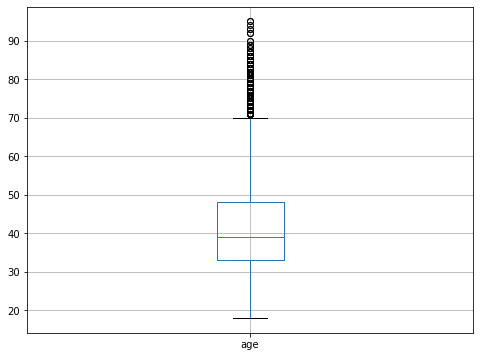

In [30]:
boxplot =updated_df.boxplot(column=['age'],figsize=(8,6))

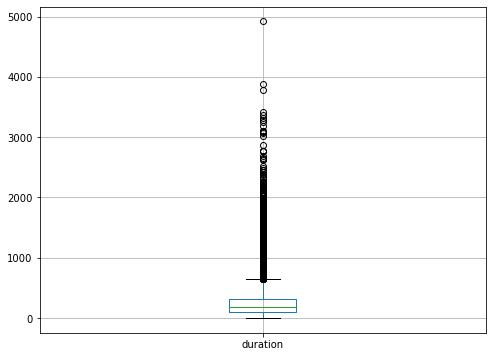

In [31]:
boxplot =updated_df.boxplot(column=['duration'],figsize=(8,6))

### split the data set

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

In [34]:
x_train_smote, x_test_smote, y_train_smote, y_test_smote = train_test_split(x_smote, y_smote, random_state=42)

In [35]:
x_train_nm, x_test_nm, y_train_nm, y_test_nm = train_test_split(x_nm, y_nm, random_state=42)

In [36]:
x_train_ros, x_test_ros, y_train_ros, y_test_ros = train_test_split(x_ros, y_ros, random_state=42)

## Voting Classifier
#### DecisionTreeClassifier
#### LogisticRegression
#### XGBClassifier


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

log_clf = LogisticRegression(solver="liblinear", random_state=42)
dt_clf = DecisionTreeClassifier(random_state=42)
XG_clf = XGBClassifier(random_state=42)

In [42]:
#for imbalanced data set
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('dt', dt_clf), ('XG', XG_clf)],
    voting='hard')

voting_clf.fit(x, y)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(random_state=42,
                                                 solver='liblinear')),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('XG',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_type...
                                            gpu_id=None, grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            predictor=None, random_state=42, ...))])

LogisticRegression [[9748  202]
 [1090  263]]


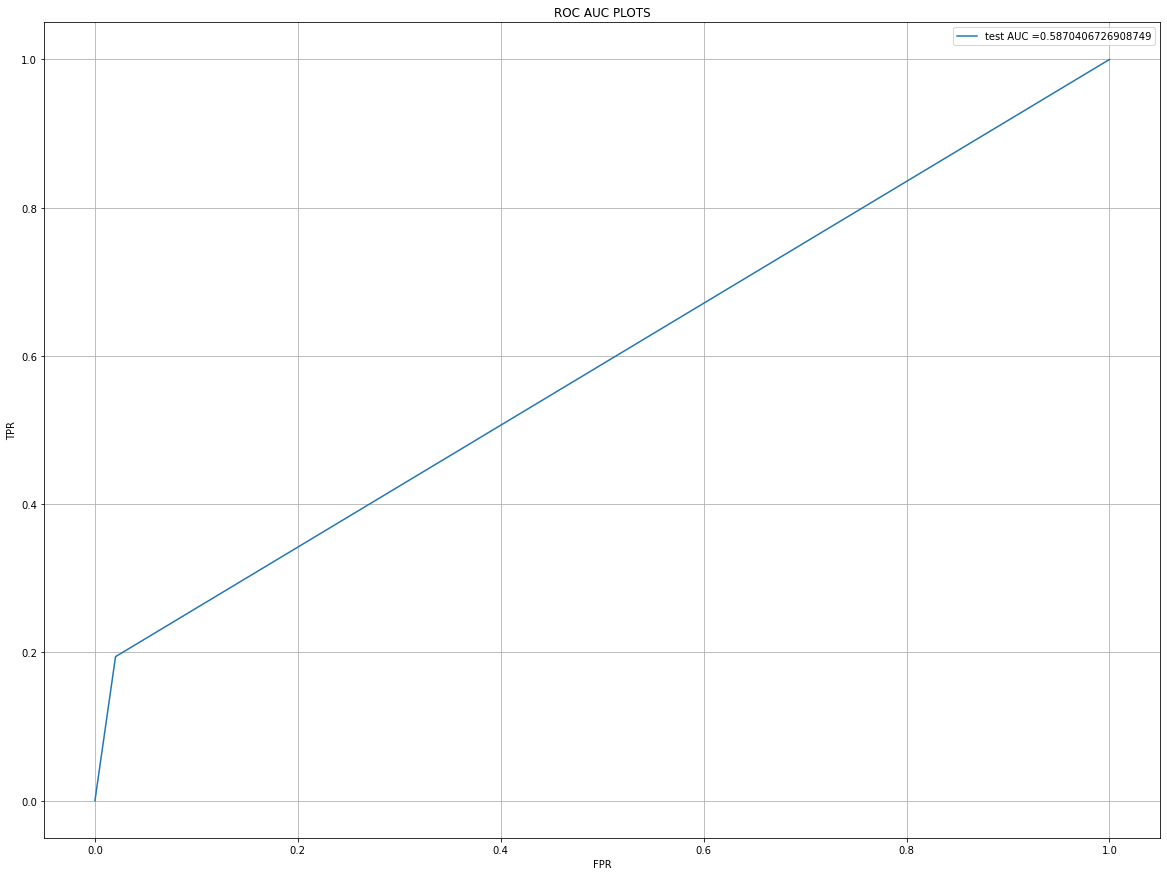

DecisionTreeClassifier [[9091  859]
 [ 785  568]]


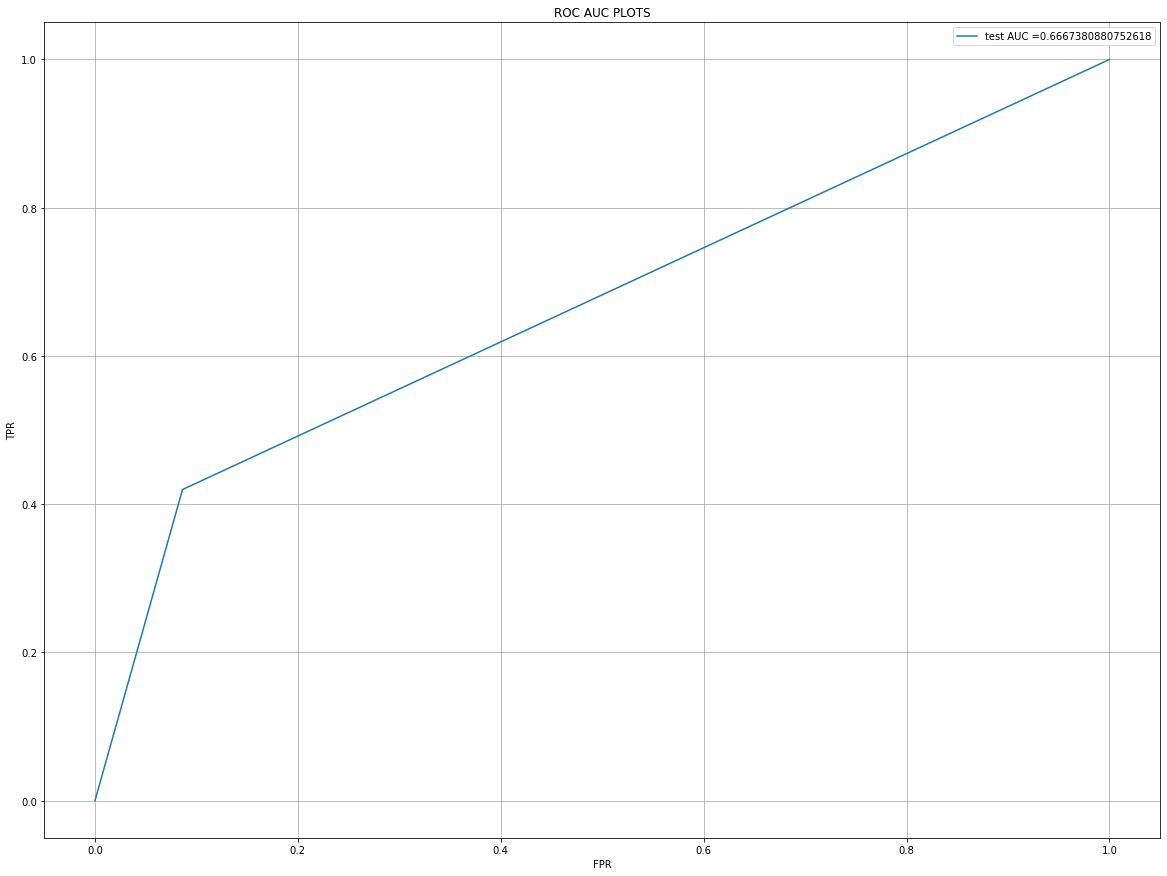

XGBClassifier [[9596  354]
 [ 819  534]]


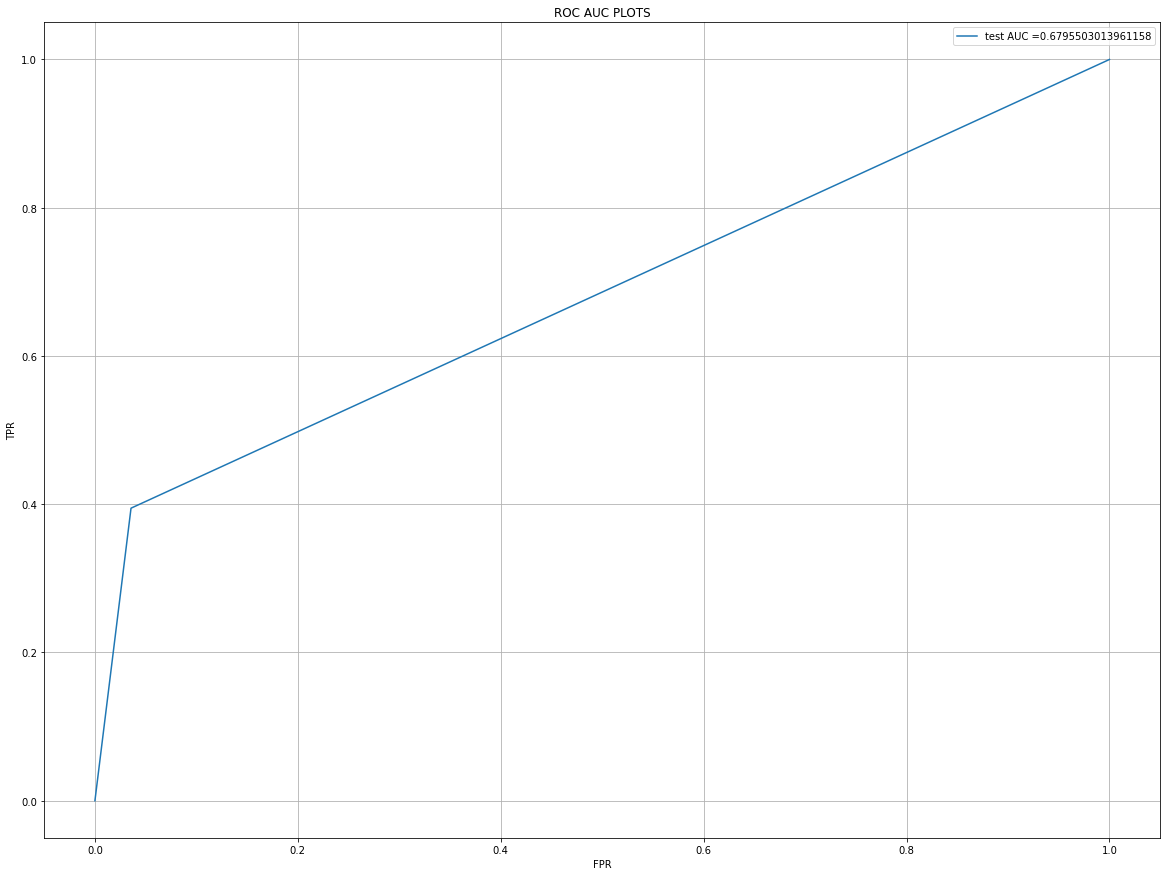

VotingClassifier [[9665  285]
 [ 925  428]]


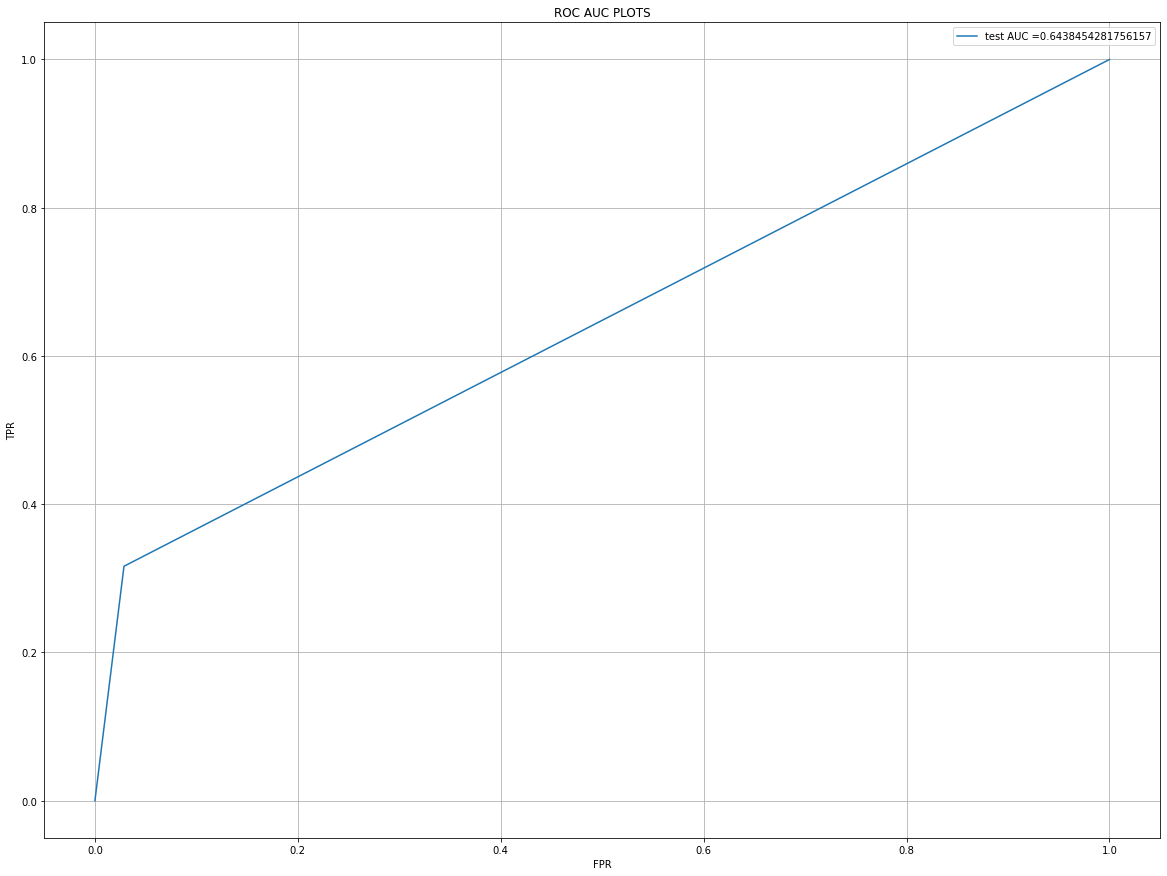

In [45]:
from sklearn.metrics import roc_auc_score 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

for clf in (log_clf, dt_clf, XG_clf, voting_clf):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    print(clf.__class__.__name__, confusion_matrix(y_test, y_pred))
    test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_pred)
    plt.figure(figsize=(20,15))
    plt.plot(test_fpr, test_tpr, label="test AUC ="+str(roc_auc_score(y_test, y_pred)))
    plt.legend()
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC AUC PLOTS")
    plt.grid()
    plt.show()

In [46]:
#for Smote_dataset
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('dt', dt_clf), ('XG', XG_clf)],
    voting='hard')

voting_clf.fit(x_smote, y_smote)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(random_state=42,
                                                 solver='liblinear')),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('XG',
                              XGBClassifier(base_score=0.5, booster='gbtree',
                                            callbacks=None, colsample_bylevel=1,
                                            colsample_bynode=1,
                                            colsample_bytree=1,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None...a=0,
                                            gpu_id=-1, grow_policy='depthwise',
                                            importance_type=None,
                                            interaction_constraints='',
                                            learning_rate=0.300000012,
                                            max_bin=256, max_cat_threshold=64,
                                            max_cat_to_onehot=4,
                                            max_delta_step=0, max_depth=6,
                                            max_leaves=0, min_child_weight=1,
                                            missing=nan,
                                            monotone_constraints='()',
                                            n_estimators=100, n_jobs=0,
                                            num_parallel_tree=1,
                                            predictor='auto', random_state=42, ...))])

LogisticRegression [[7885 2064]
 [2794 7218]]


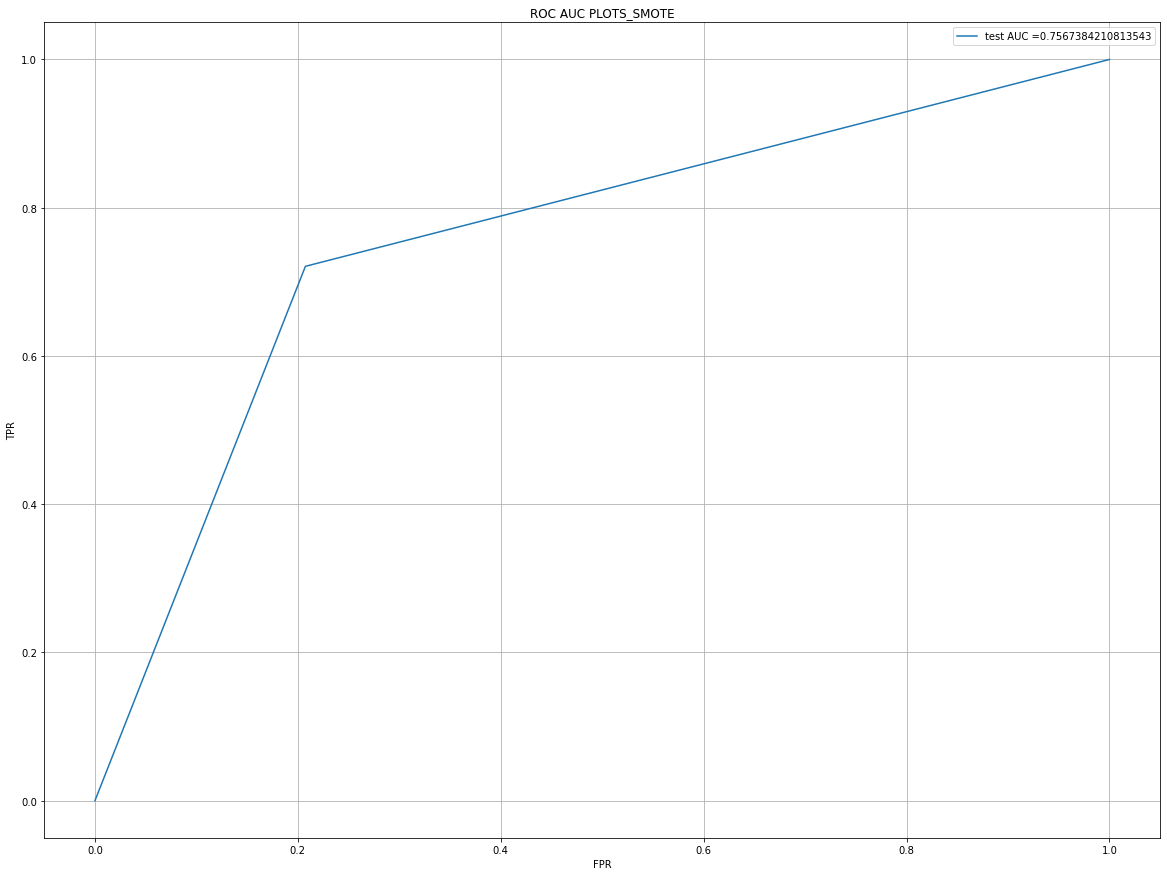

DecisionTreeClassifier [[8786 1163]
 [ 998 9014]]


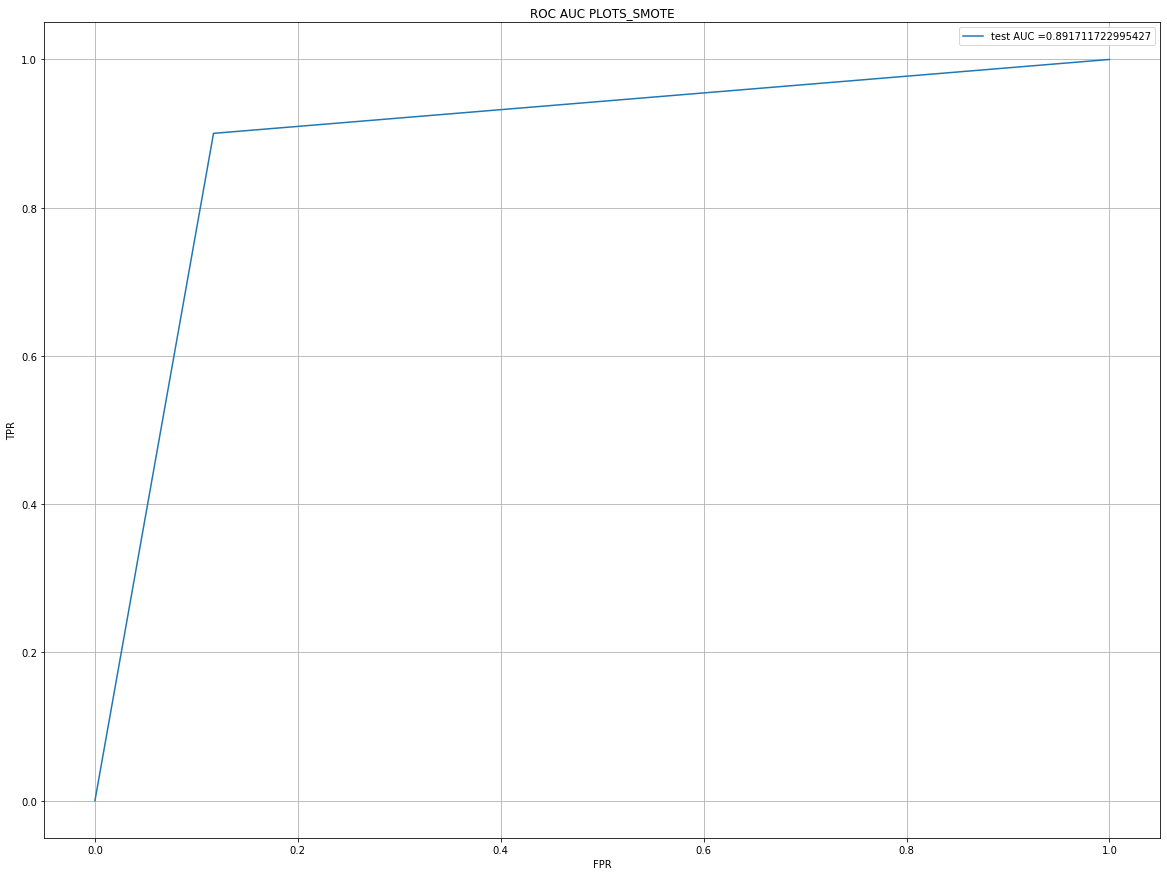

XGBClassifier [[9557  392]
 [ 804 9208]]


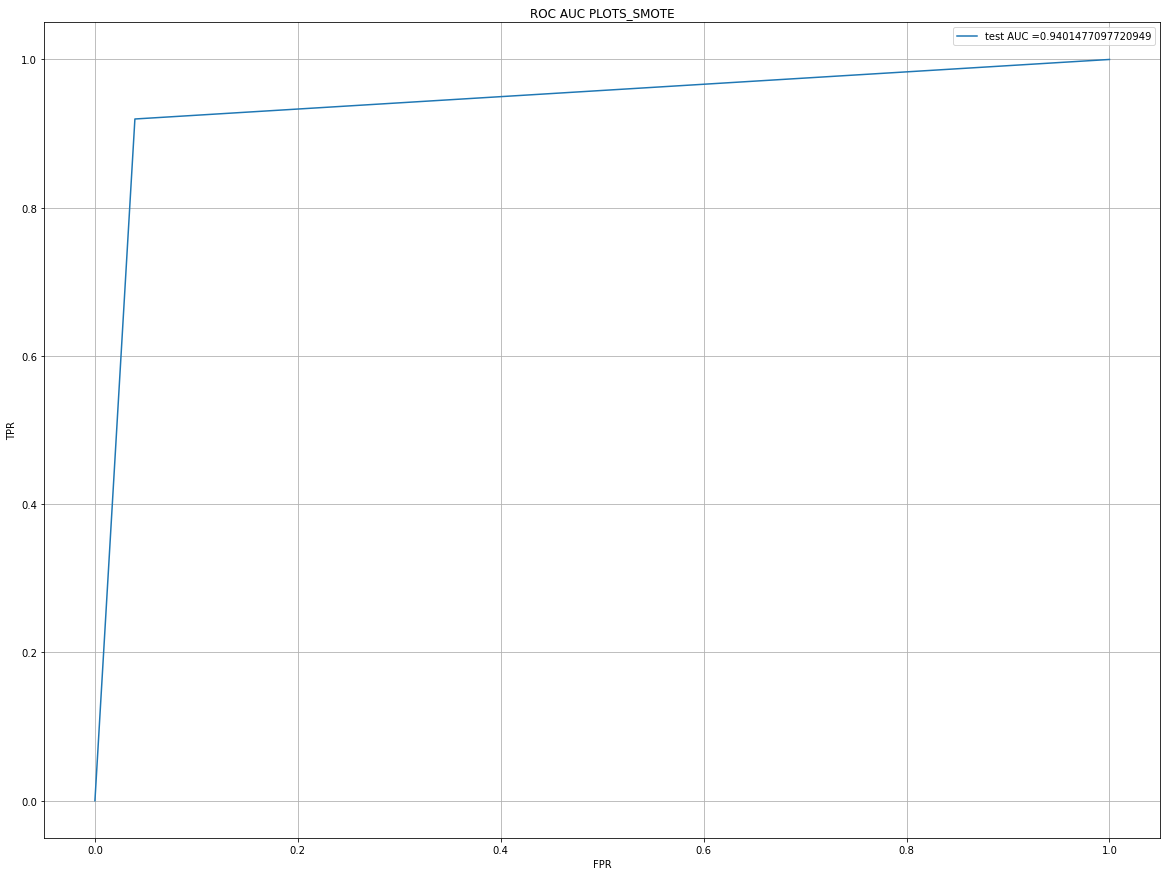

VotingClassifier [[9104  845]
 [ 788 9224]]


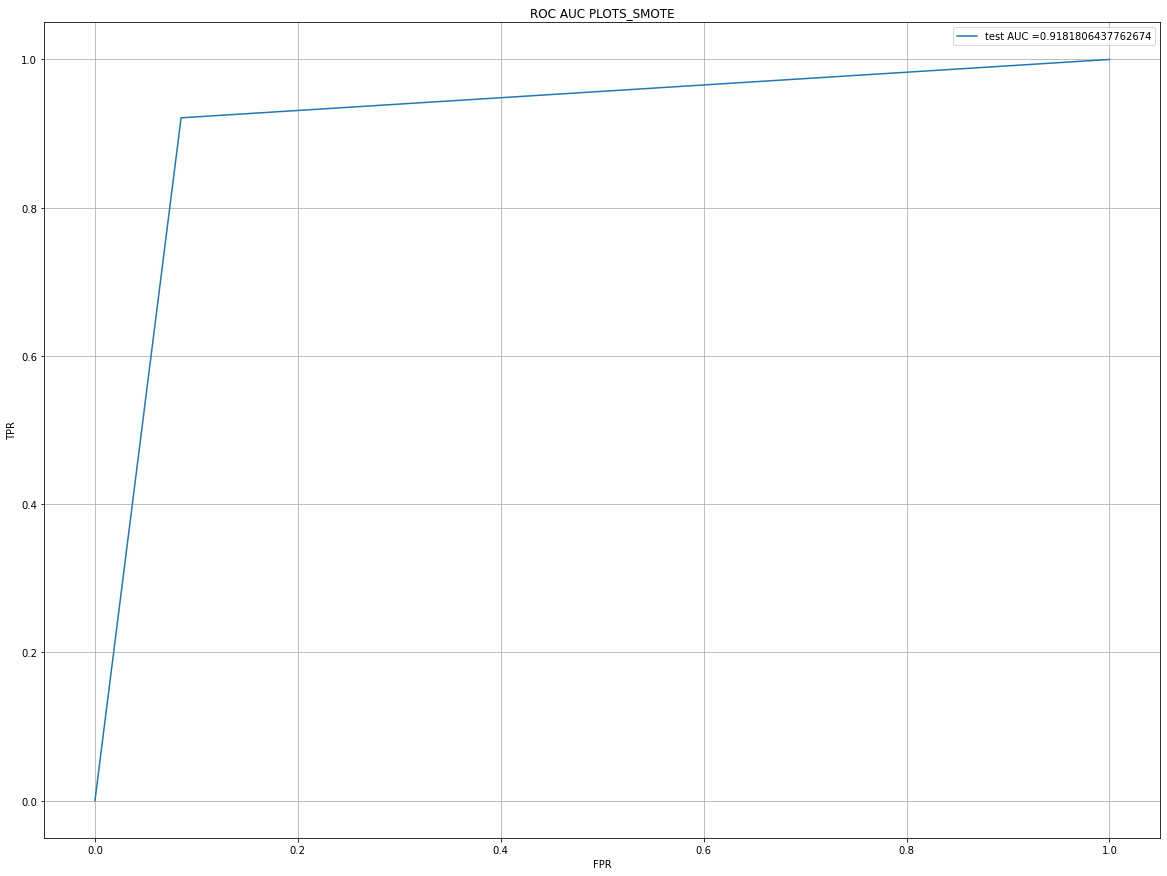

In [47]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

for clf in (log_clf, dt_clf, XG_clf, voting_clf):
    clf.fit(x_train_smote, y_train_smote)
    y_pred_smote = clf.predict(x_test_smote)
    print(clf.__class__.__name__, confusion_matrix(y_test_smote, y_pred_smote))
    test_fpr, test_tpr, te_thresholds = roc_curve(y_test_smote, y_pred_smote)
    plt.figure(figsize=(20,15))
    plt.plot(test_fpr, test_tpr, label="test AUC ="+str(roc_auc_score(y_test_smote, y_pred_smote)))
    plt.legend()
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC AUC PLOTS_SMOTE")
    plt.grid()
    plt.show()

In [48]:
#for NearMiss_Dataset
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('dt', dt_clf), ('XG', XG_clf)],
    voting='hard')

voting_clf.fit(x_nm, y_nm)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(random_state=42,
                                                 solver='liblinear')),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('XG',
                              XGBClassifier(base_score=0.5, booster='gbtree',
                                            callbacks=None, colsample_bylevel=1,
                                            colsample_bynode=1,
                                            colsample_bytree=1,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None...a=0,
                                            gpu_id=-1, grow_policy='depthwise',
                                            importance_type=None,
                                            interaction_constraints='',
                                            learning_rate=0.300000012,
                                            max_bin=256, max_cat_threshold=64,
                                            max_cat_to_onehot=4,
                                            max_delta_step=0, max_depth=6,
                                            max_leaves=0, min_child_weight=1,
                                            missing=nan,
                                            monotone_constraints='()',
                                            n_estimators=100, n_jobs=0,
                                            num_parallel_tree=1,
                                            predictor='auto', random_state=42, ...))])

LogisticRegression [[1249  109]
 [ 207 1080]]


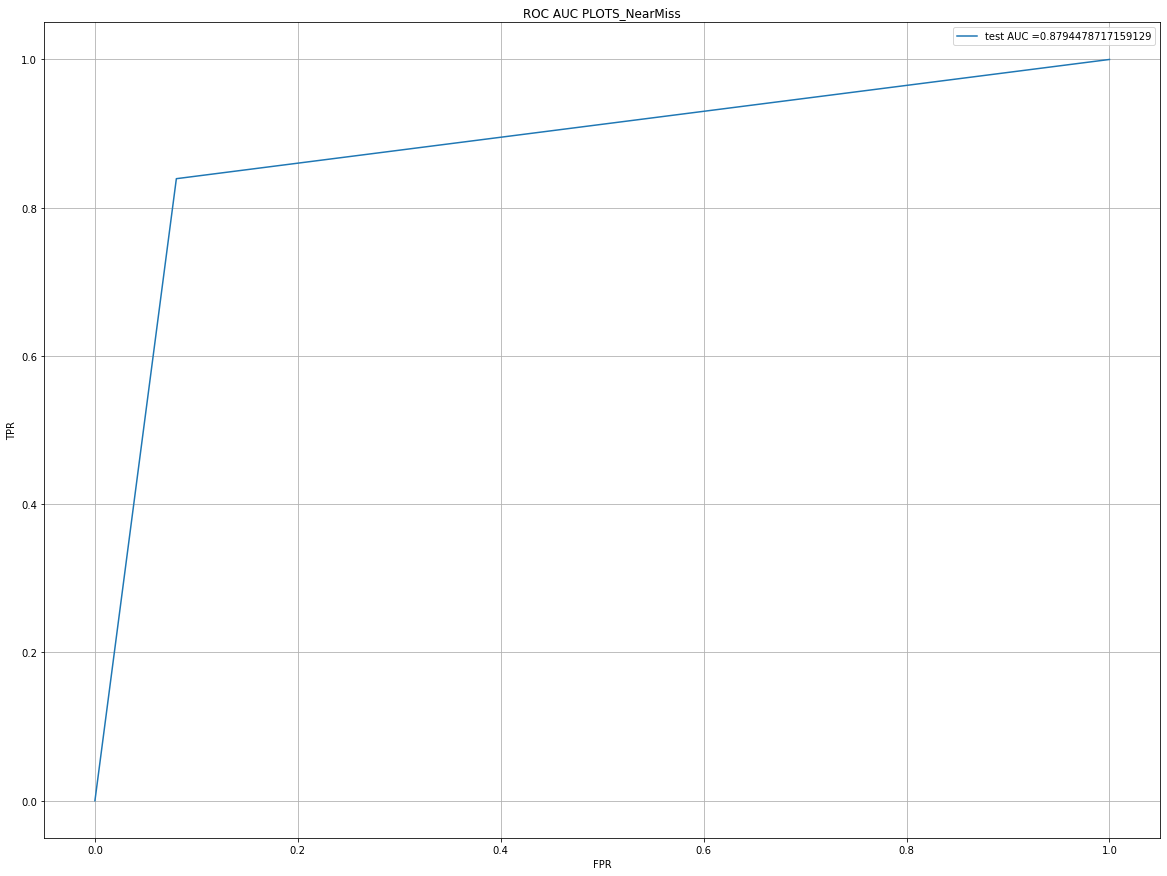

DecisionTreeClassifier [[1164  194]
 [ 180 1107]]


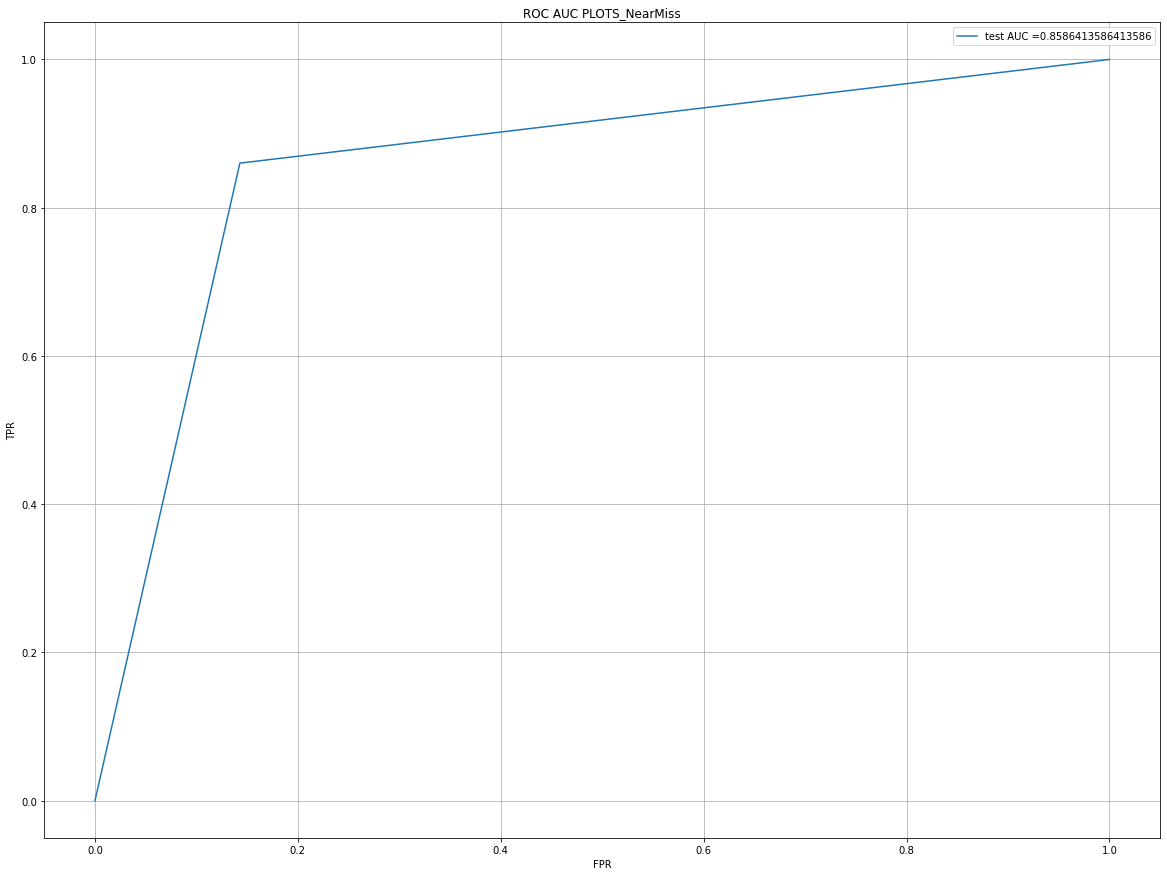

XGBClassifier [[1253  105]
 [ 152 1135]]


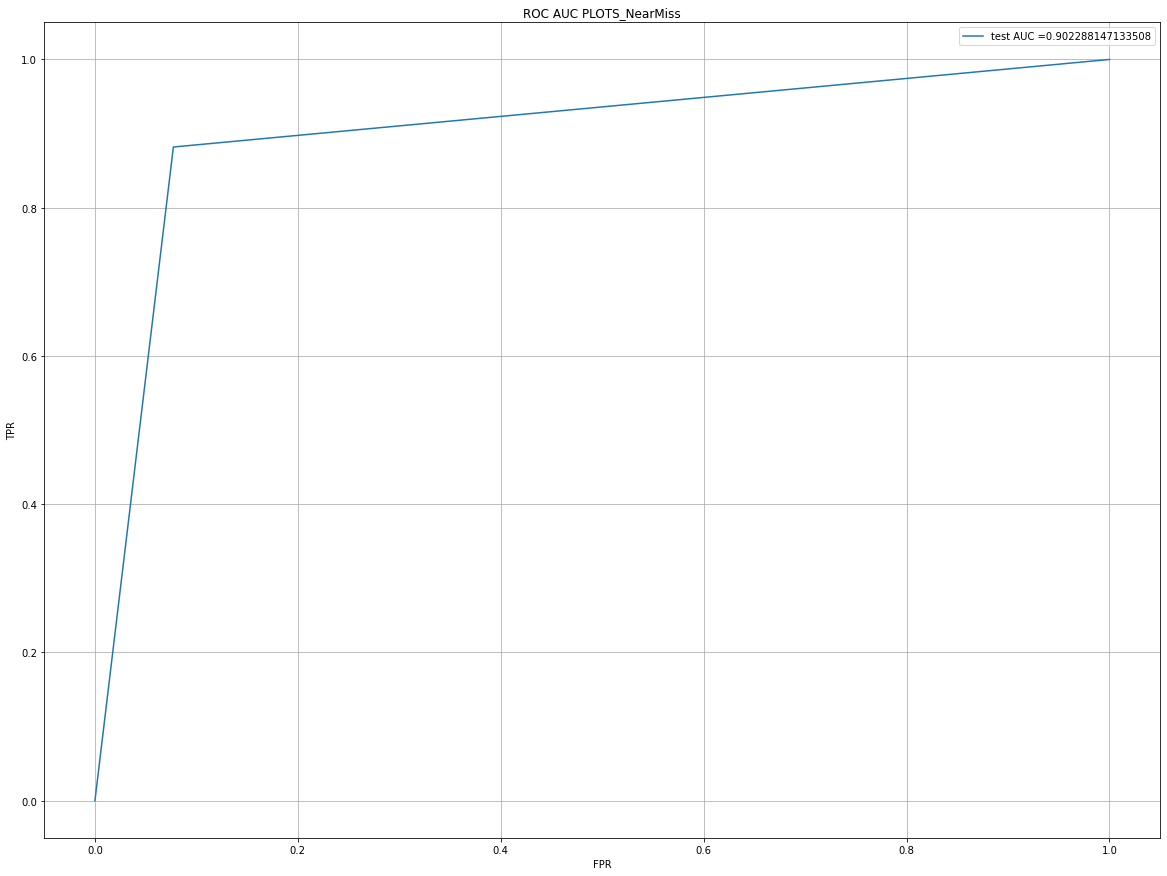

VotingClassifier [[1250  108]
 [ 165 1122]]


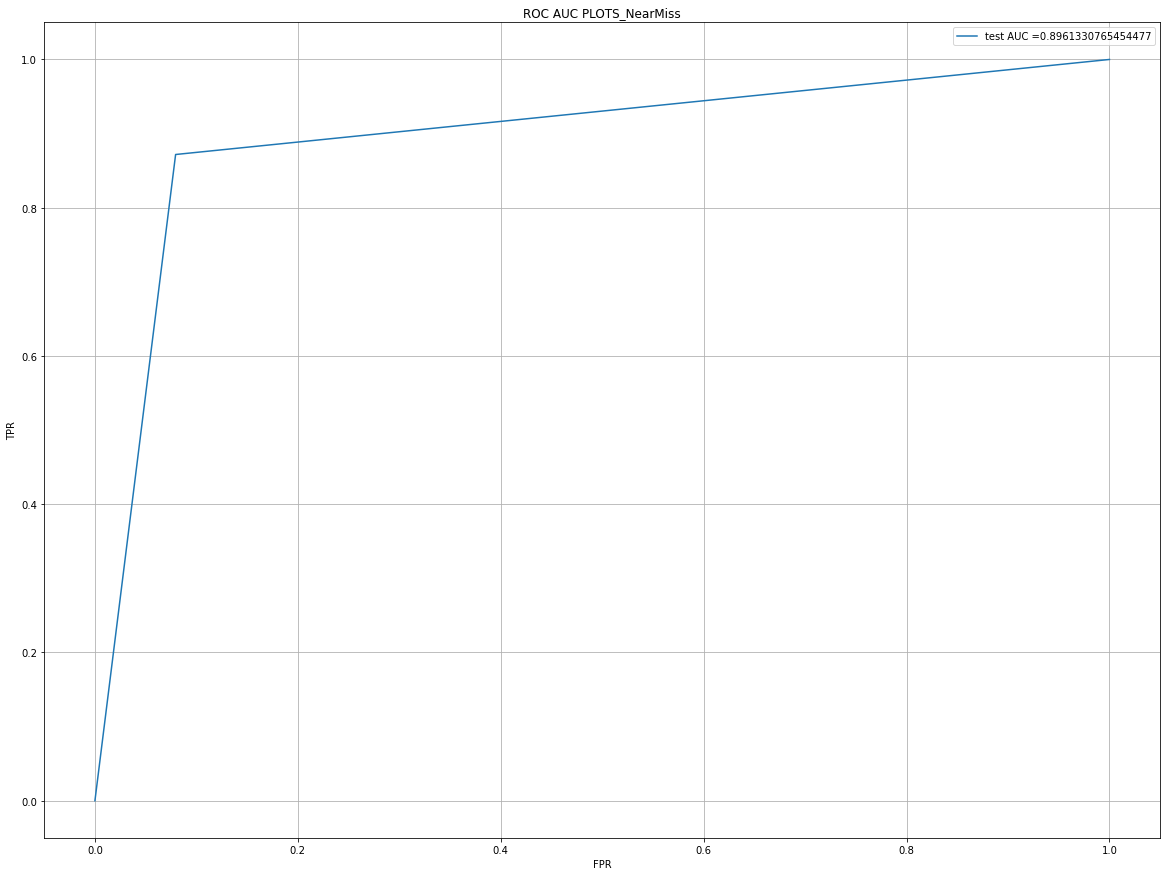

In [49]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

for clf in (log_clf, dt_clf, XG_clf, voting_clf):
    clf.fit(x_train_nm, y_train_nm)
    y_pred_nm = clf.predict(x_test_nm)
    print(clf.__class__.__name__, confusion_matrix(y_test_nm, y_pred_nm))
    test_fpr, test_tpr, te_thresholds = roc_curve(y_test_nm, y_pred_nm)
    plt.figure(figsize=(20,15))
    plt.plot(test_fpr, test_tpr, label="test AUC ="+str(roc_auc_score(y_test_nm, y_pred_nm)))
    plt.legend()
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC AUC PLOTS_NearMiss")
    plt.grid()
    plt.show()

In [50]:
#for RandomOverSampling_dataset
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('dt', dt_clf), ('XG', XG_clf)],
    voting='hard')

voting_clf.fit(x_ros, y_ros)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(random_state=42,
                                                 solver='liblinear')),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('XG',
                              XGBClassifier(base_score=0.5, booster='gbtree',
                                            callbacks=None, colsample_bylevel=1,
                                            colsample_bynode=1,
                                            colsample_bytree=1,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None...a=0,
                                            gpu_id=-1, grow_policy='depthwise',
                                            importance_type=None,
                                            interaction_constraints='',
                                            learning_rate=0.300000012,
                                            max_bin=256, max_cat_threshold=64,
                                            max_cat_to_onehot=4,
                                            max_delta_step=0, max_depth=6,
                                            max_leaves=0, min_child_weight=1,
                                            missing=nan,
                                            monotone_constraints='()',
                                            n_estimators=100, n_jobs=0,
                                            num_parallel_tree=1,
                                            predictor='auto', random_state=42, ...))])

LogisticRegression [[7984 1965]
 [2379 7633]]


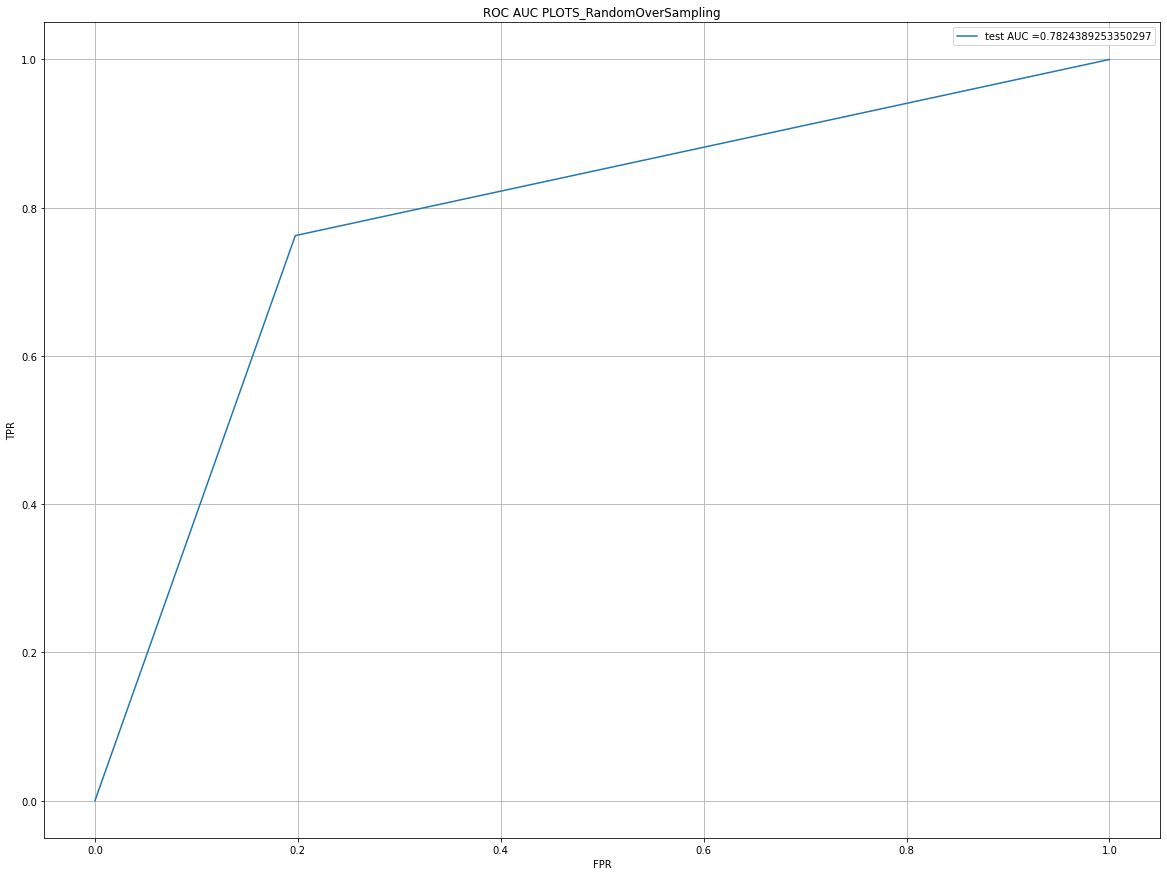

DecisionTreeClassifier [[ 9000   949]
 [   11 10001]]


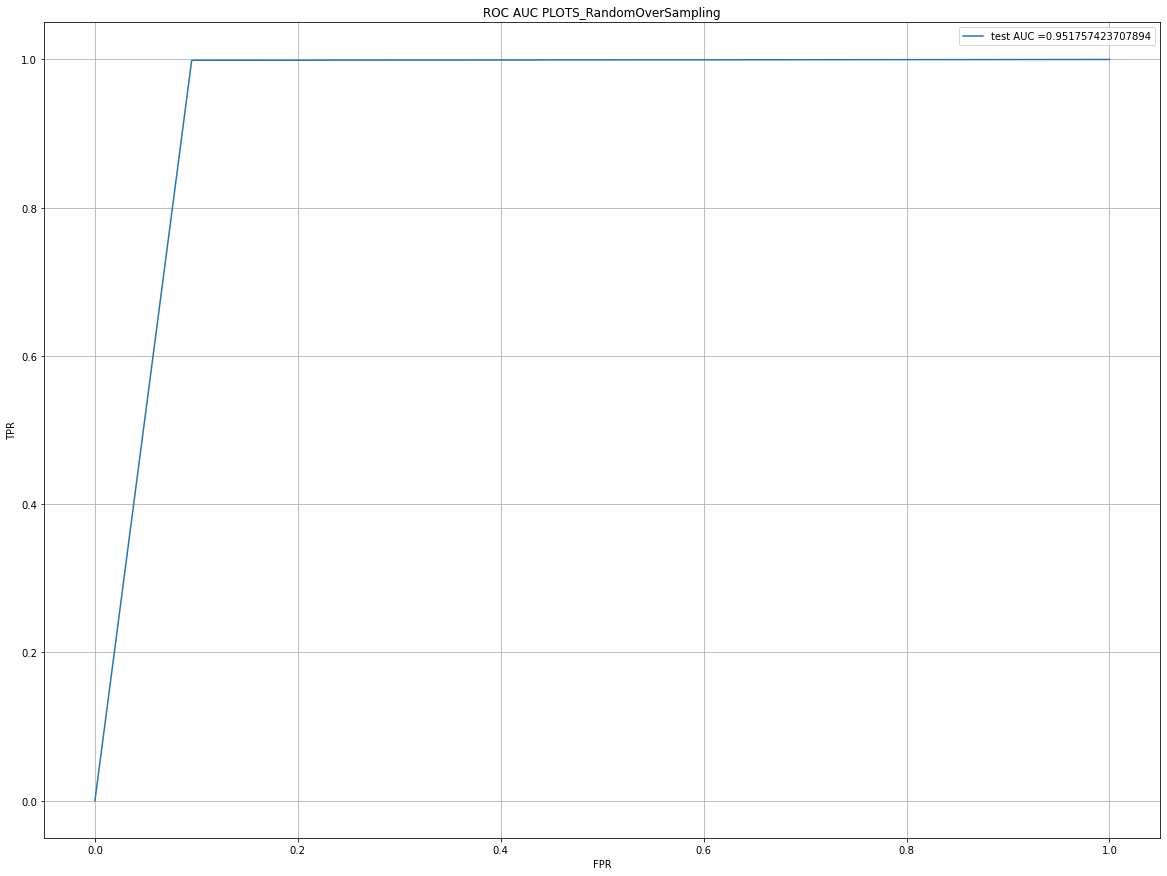

XGBClassifier [[8440 1509]
 [ 882 9130]]


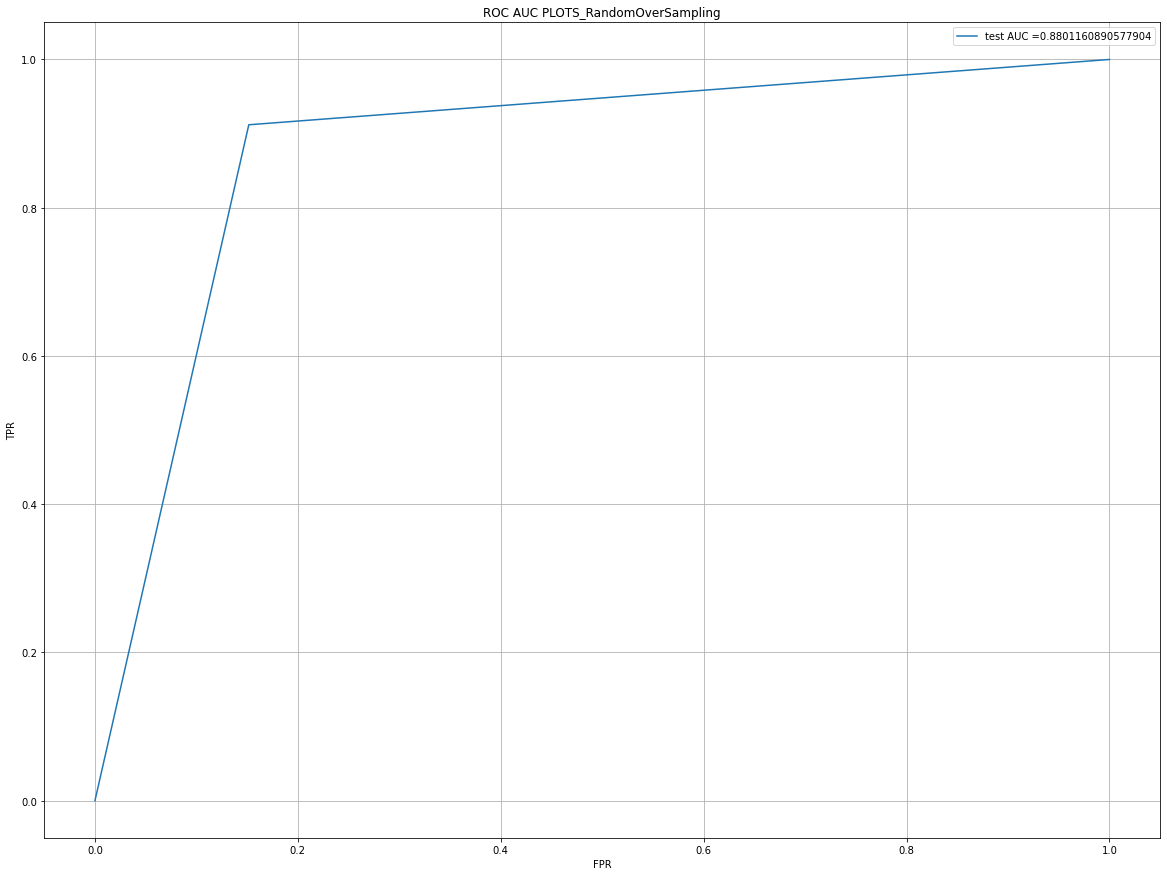

VotingClassifier [[8544 1405]
 [ 755 9257]]


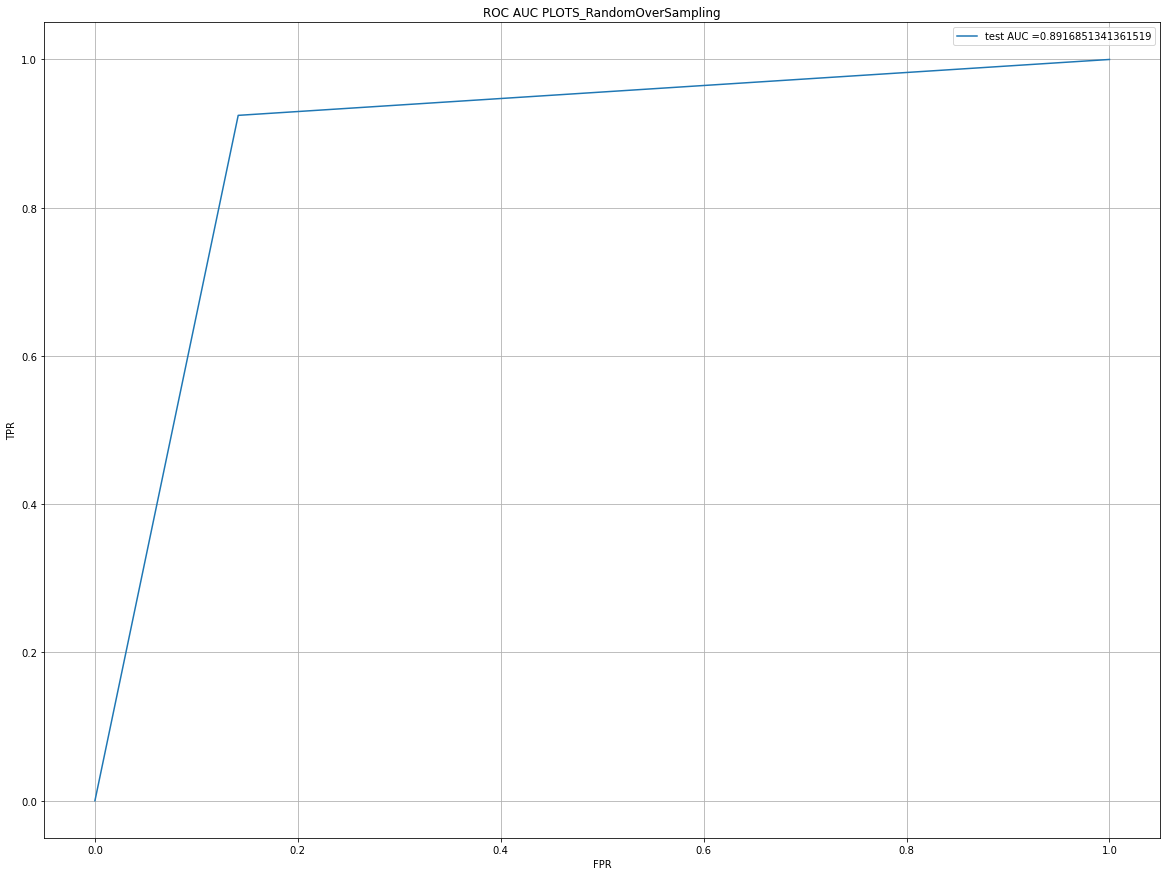

In [51]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

for clf in (log_clf, dt_clf, XG_clf, voting_clf):
    clf.fit(x_train_ros, y_train_ros)
    y_pred_ros = clf.predict(x_test_ros)
    print(clf.__class__.__name__, confusion_matrix(y_test_ros, y_pred_ros))
    test_fpr, test_tpr, te_thresholds = roc_curve(y_test_ros, y_pred_ros)
    plt.figure(figsize=(20,15))
    plt.plot(test_fpr, test_tpr, label="test AUC ="+str(roc_auc_score(y_test_ros, y_pred_ros)))
    plt.legend()
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC AUC PLOTS_RandomOverSampling")
    plt.grid()
    plt.show()